# Prédiction du Risque de Décès chez les Patients Atteints de Leucémie Myéloïde
## Data Challenge QRT × Institut Gustave Roussy

**Cours :** Master 2 IEF ; Machine Learning  
**Année :** 2025/2026

---

## 1. Introduction et Contexte du Challenge

### 1.1 Contexte Médical

Les leucémies myéloïdes sont un groupe de cancers du sang caractérisés par une prolifération anormale de cellules dans la moelle osseuse. Le pronostic de ces patients varie considérablement : certains patients présentent une forme indolente de la maladie tandis que d'autres font face à un pronostic sévère nécessitant des traitements intensifs comme la greffe de cellules souches hématopoïétiques.

**Pourquoi est-ce important ?** L'estimation précise du risque permet d'**adapter la stratégie thérapeutique** :
- Les patients à **faible risque** reçoivent des soins de support visant à améliorer la qualité de vie.
- Les patients à **haut risque** sont orientés vers des traitements plus agressifs, potentiellement curatifs.

### 1.2 Objectif du Challenge

L'objectif est de **prédire le risque de décès** pour chaque patient, à partir de données cliniques (paramètres sanguins, caryotype) et moléculaires (mutations somatiques). La prédiction prend la forme d'un **score de risque** : seul l'**ordre relatif** entre patients importe (un score plus élevé = risque plus élevé).

### 1.3 Métrique d'Évaluation : IPCW C-index

La métrique utilisée est l'**indice de concordance avec pondération inverse de la censure** (IPCW C-index), tronqué à 7 ans.

**Indice de concordance (C-index) :** Pour un ensemble de paires comparables $(i,j)$ avec $T_i < T_j$, le C-index mesure la proportion de paires pour lesquelles le score de risque prédit est cohérent avec le temps de survie observé :

$$C = \frac{\sum_{i,j} \mathbb{1}[\hat{R}_i > \hat{R}_j] \cdot \mathbb{1}[T_i < T_j] \cdot \delta_i}{\sum_{i,j} \mathbb{1}[T_i < T_j] \cdot \delta_i}$$

où $\hat{R}_i$ est le risque prédit, $T_i$ le temps de survie observé, et $\delta_i$ l'indicateur d'événement (1 = décès, 0 = censuré).

**Problème de la censure à droite :** Certains patients sont encore en vie au dernier suivi. On ne connaît donc pas leur temps de survie réel, seulement une borne inférieure. L'IPCW corrige ce biais en **pondérant** chaque observation par l'inverse de la probabilité d'être censuré, estimée par un estimateur de Kaplan-Meier de la distribution de censure :

$$C_{\text{IPCW}} = \frac{\sum_{i,j} w_i \cdot w_j \cdot \mathbb{1}[\hat{R}_i > \hat{R}_j] \cdot \mathbb{1}[T_i < T_j] \cdot \delta_i}{\sum_{i,j} w_i \cdot w_j \cdot \mathbb{1}[T_i < T_j] \cdot \delta_i}$$

avec $w_i = 1 / \hat{G}(T_i)$, où $\hat{G}$ est l'estimateur de Kaplan-Meier de la fonction de survie de la censure.

- $C = 1$ : concordance parfaite  
- $C = 0.5$ : modèle aléatoire

### 1.4 Notre Approche

Notre démarche sera la suivante :
1. **Analyse exploratoire** des données cliniques et moléculaires
2. **Feature engineering** pour construire des variables explicatives pertinentes
3. **Modèle de référence** : Régression de Cox (modèle linéaire de survie)
4. **Approche non supervisée** : Clustering K-Means pour identifier des profils de patients
5. **Modèle supervisé ensembliste** : Random Survival Forest
6. **Modèle de deep learning** : Perceptron Multi-Couches (MLP)
7. **Comparaison et interprétation** des résultats

## 2. Chargement et Description des Données

### 2.1 Description des Variables

Les données sont réparties en deux jeux :

**Données Cliniques** (1 ligne/patient) ; Paramètres sanguins et cytogénétiques :
- `BM_BLAST` : Pourcentage de blastes dans la moelle osseuse (cellules anormales)
- `WBC` : Nombre de globules blancs (Giga/L)
- `ANC` : Nombre absolu de neutrophiles (Giga/L)
- `MONOCYTES` : Nombre de monocytes (Giga/L)
- `HB` : Hémoglobine (g/dL)
- `PLT` : Plaquettes (Giga/L)
- `CYTOGENETICS` : Description du caryotype (anomalies chromosomiques)
- `CENTER` : Centre clinique de traitement

**Données Moléculaires** (1 ligne/mutation/patient) ; Mutations somatiques des cellules tumorales :
- `GENE` : Gène affecté par la mutation
- `EFFECT` : Type d'effet de la mutation
- `VAF` : Fraction allélique variante (proportion de cellules portant la mutation)
- `CHR, START, END, REF, ALT` : Coordonnées génomiques

**Variable Cible :**
- `OS_YEARS` : Temps de survie globale en années
- `OS_STATUS` : 1 = décès, 0 = vivant au dernier suivi (censuré)

In [1]:
#  Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_ipcw, concordance_index_censored
from sksurv.util import Surv

import lightgbm as lgb

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Imports effectués avec succès.")

Imports effectués avec succès.


In [2]:
#  Chargement des données 
# On suppose que tous les fichiers sont à la racine du projet
clinical_train = pd.read_csv("./clinical_train.csv")
molecular_train = pd.read_csv("./molecular_train.csv")
clinical_test = pd.read_csv("./clinical_test.csv")
molecular_test = pd.read_csv("./molecular_test.csv")
target_train = pd.read_csv("./target_train.csv")

print(f"Données cliniques (train) : {clinical_train.shape[0]} patients, {clinical_train.shape[1]} variables")
print(f"Données moléculaires (train) : {molecular_train.shape[0]} mutations, {molecular_train['ID'].nunique()} patients")
print(f"Données cliniques (test) : {clinical_test.shape[0]} patients")
print(f"Données moléculaires (test) : {molecular_test.shape[0]} mutations, {molecular_test['ID'].nunique()} patients")
print(f"\nVariable cible : {target_train.shape[0]} patients")
print(f"Colonnes cible : {target_train.columns.tolist()}")

Données cliniques (train) : 3323 patients, 9 variables
Données moléculaires (train) : 10935 mutations, 3026 patients
Données cliniques (test) : 1193 patients
Données moléculaires (test) : 3089 mutations, 1054 patients

Variable cible : 3323 patients
Colonnes cible : ['ID', 'OS_YEARS', 'OS_STATUS']


In [3]:
# Aperçu des données cliniques
clinical_train.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [4]:
# Aperçu des données moléculaires
molecular_train.head()

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0


In [5]:
# Aperçu de la variable cible
target_train.head()

,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Variable Cible : Survie Globale

Commençons par examiner la distribution de notre variable cible. Il est crucial de comprendre la **proportion de censure**, car elle impacte directement la fiabilité de nos modèles : un taux de censure élevé signifie que pour beaucoup de patients, on ne connaît pas le temps de survie réel mais seulement une borne inférieure.

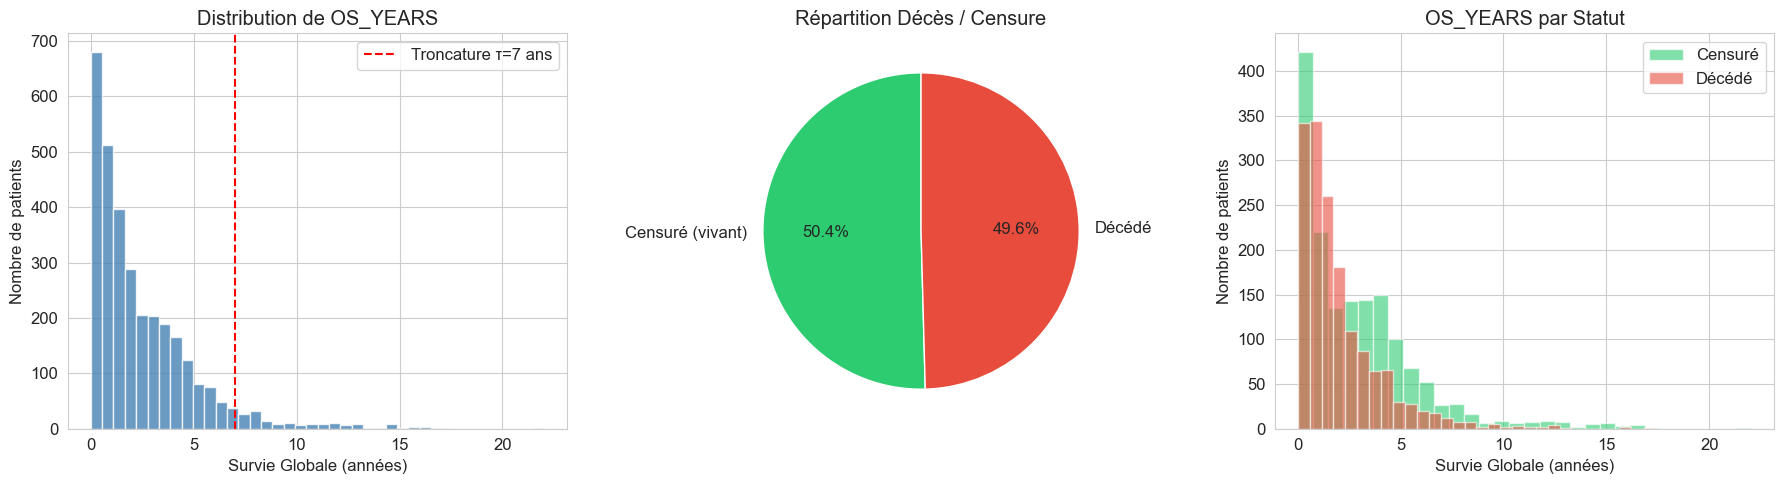

Temps de survie médian : 1.65 ans
Taux de censure : 47.3%
Taux de décès : 48.1%


In [6]:
#  Analyse de la variable cible 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution de OS_YEARS
axes[0].hist(target_train['OS_YEARS'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Survie Globale (années)')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_title('Distribution de OS_YEARS')
axes[0].axvline(x=7, color='red', linestyle='--', label='Troncature τ=7 ans')
axes[0].legend()

# Proportion de censure
status_counts = target_train['OS_STATUS'].value_counts()
labels = ['Censuré (vivant)', 'Décédé']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(status_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Répartition Décès / Censure')

# Distribution de OS_YEARS par statut
for status, label, color in [(0, 'Censuré', '#2ecc71'), (1, 'Décédé', '#e74c3c')]:
    subset = target_train[target_train['OS_STATUS'] == status]
    axes[2].hist(subset['OS_YEARS'], bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[2].set_xlabel('Survie Globale (années)')
axes[2].set_ylabel('Nombre de patients')
axes[2].set_title('OS_YEARS par Statut')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Temps de survie médian : {target_train['OS_YEARS'].median():.2f} ans")
print(f"Taux de censure : {(target_train['OS_STATUS'] == 0).mean()*100:.1f}%")
print(f"Taux de décès : {(target_train['OS_STATUS'] == 1).mean()*100:.1f}%")

Note : ~4.5% des patients ont un OS_STATUS manquant (ni 0 ni 1).
Ils seront exclus lors de la préparation des données (section 5).

### 3.2 Données Cliniques : Statistiques Descriptives et Valeurs Manquantes

Les variables cliniques correspondent à des paramètres sanguins mesurés au diagnostic. Analysons leurs distributions et la présence de valeurs manquantes, qui devront être traitées avant la modélisation.

In [7]:
#  Valeurs manquantes 
missing = clinical_train.isnull().sum()
missing_pct = (clinical_train.isnull().sum() / len(clinical_train) * 100).round(1)
missing_df = pd.DataFrame({'Manquantes': missing, '% Manquant': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('% Manquant', ascending=False)
print("Valeurs manquantes dans les données cliniques :")
print(missing_df)
print(f"\nTotal de patients : {len(clinical_train)}")

Valeurs manquantes dans les données cliniques :
              Manquantes  % Manquant
MONOCYTES            601        18.1
CYTOGENETICS         387        11.6
WBC                  272         8.2
ANC                  193         5.8
PLT                  124         3.7
BM_BLAST             109         3.3
HB                   110         3.3

Total de patients : 3323


In [8]:
#  Statistiques descriptives des variables numériques 
num_cols = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
clinical_train[num_cols].describe().round(2)

,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3214.00,3051.00,3130.00,2722.00,3213.00,3199.00
mean,5.98,6.54,3.26,0.96,9.89,167.05
std,7.62,10.25,5.24,2.67,2.04,149.48
min,0.00,0.20,0.00,0.00,4.00,2.00
25%,1.00,2.70,1.00,0.15,8.50,65.50
50%,3.00,4.10,2.00,0.37,9.70,123.00
75%,8.00,6.66,3.69,0.78,11.20,229.50
max,91.00,154.40,109.62,44.20,16.60,1451.00


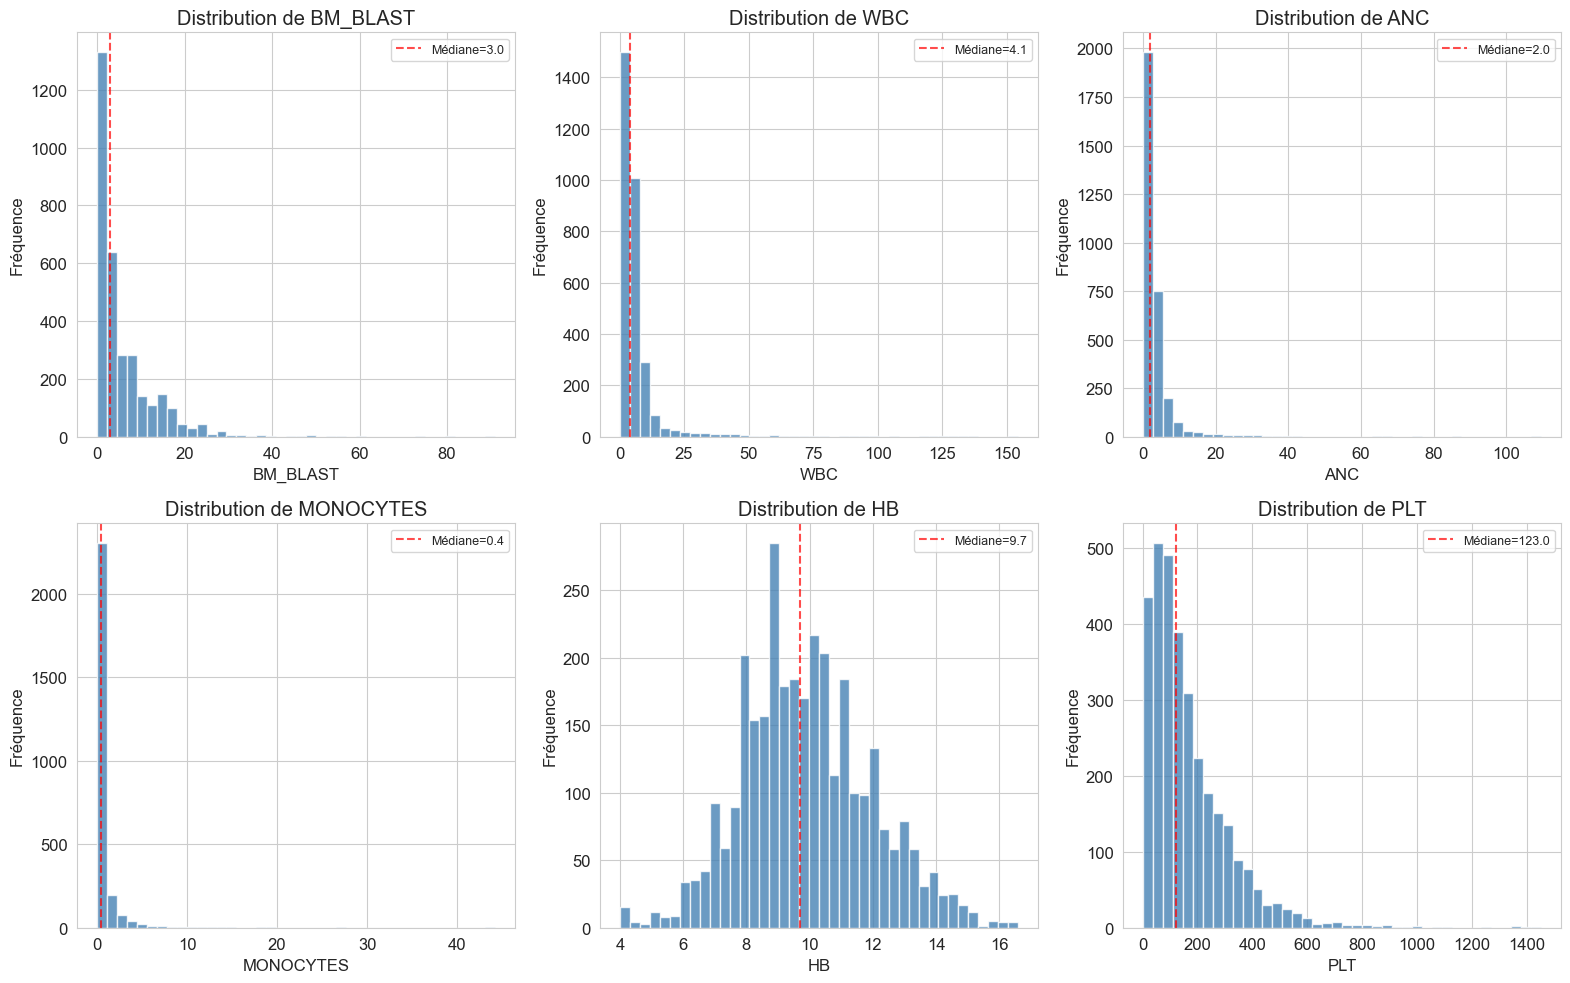

In [9]:
#  Distributions des variables cliniques 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(clinical_train[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    # Ajouter la médiane
    med = clinical_train[col].median()
    axes[i].axvline(x=med, color='red', linestyle='--', alpha=0.7, label=f'Médiane={med:.1f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Observations :**
- `BM_BLAST` (blastes) : distribution fortement asymétrique à droite ; la majorité des patients ont un faible pourcentage de blastes, mais certains en ont beaucoup (>50%), signe d'une forme plus agressive.
- `WBC` (globules blancs) : distribution asymétrique avec quelques valeurs extrêmes très élevées.
- `HB` (hémoglobine) : distribution approximativement symétrique, centrée autour de 10 g/dL, ce qui indique une anémie fréquente chez ces patients.
- `PLT` (plaquettes) : distribution très asymétrique, certaines valeurs très élevées (thrombocytose).
- Les variables `MONOCYTES` et `ANC` présentent aussi des asymétries marquées.

Le taux de valeurs manquantes est modéré (3-18%), nous utiliserons une **imputation par la médiane**, stratégie robuste face aux distributions asymétriques.

### 3.3 Corrélations entre Variables Cliniques

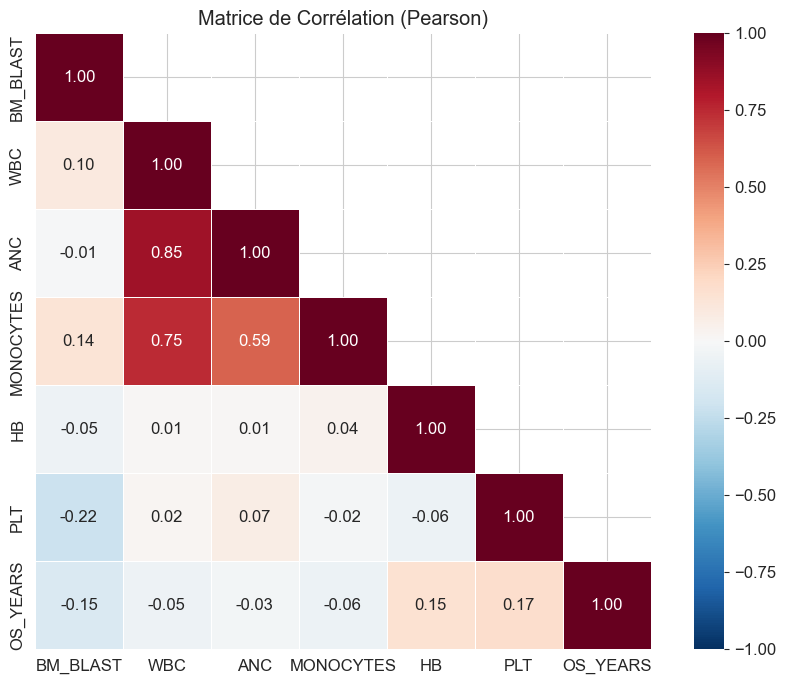

In [10]:
#  Matrice de corrélation 
# On fusionne les données cliniques avec la cible pour analyser les corrélations avec OS_YEARS
df_merged = clinical_train.merge(target_train, on='ID')
corr_cols = num_cols + ['OS_YEARS']
corr_matrix = df_merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Matrice de Corrélation (Pearson)')
plt.tight_layout()
plt.show()

**Analyse des corrélations :**
- `WBC` et `ANC` sont fortement corrélées (les neutrophiles sont un sous-type de globules blancs), ce qui est attendu biologiquement. Cela peut poser des problèmes de **multicolinéarité** dans les modèles linéaires.
- `HB` montre une corrélation positive avec `OS_YEARS` : une hémoglobine plus élevée est associée à une meilleure survie (ce qui est cliniquement cohérent ; l'anémie est un facteur de mauvais pronostic).
- `BM_BLAST` montre une corrélation négative avec `OS_YEARS` : un pourcentage élevé de blastes est associé à une survie plus courte.

### 3.4 Survie par Variables Cliniques (analyse bivariée)

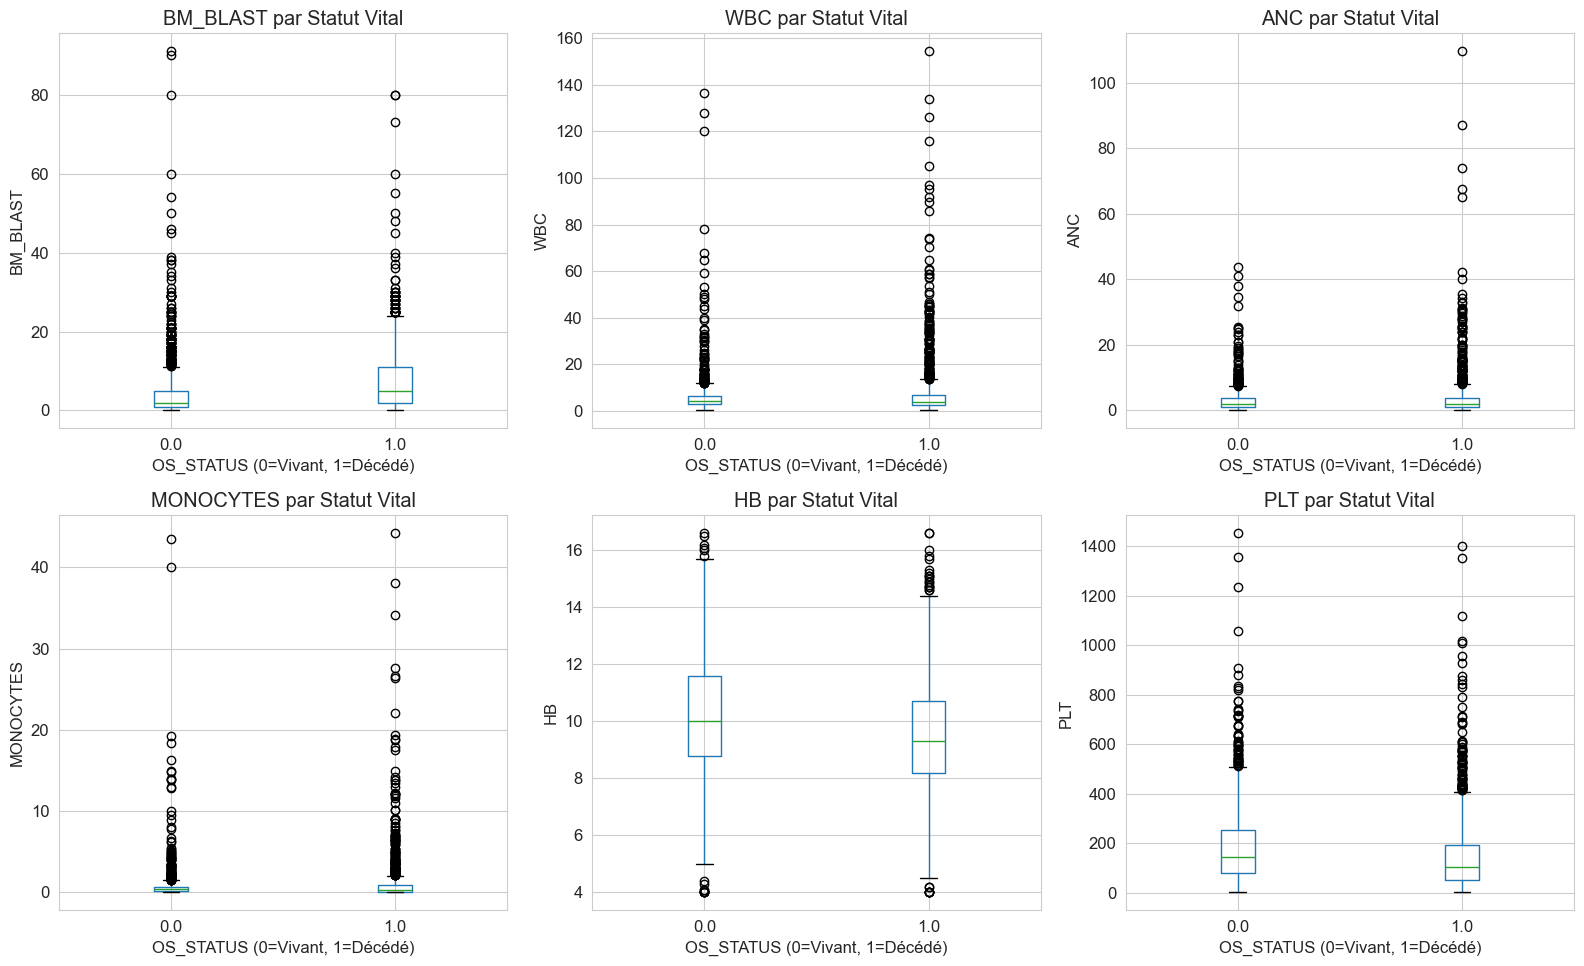

In [11]:
#  Boxplots des variables cliniques selon le statut vital 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_merged.boxplot(column=col, by='OS_STATUS', ax=axes[i])
    axes[i].set_title(f'{col} par Statut Vital')
    axes[i].set_xlabel('OS_STATUS (0=Vivant, 1=Décédé)')
    axes[i].set_ylabel(col)

plt.suptitle('')  # Remove auto title
plt.tight_layout()
plt.show()

### 3.5 Analyse des Données Moléculaires

Les données moléculaires contiennent les mutations somatiques détectées dans les cellules tumorales. Chaque patient peut avoir zéro, une ou plusieurs mutations. Analysons la distribution du nombre de mutations et les gènes les plus fréquemment mutés.

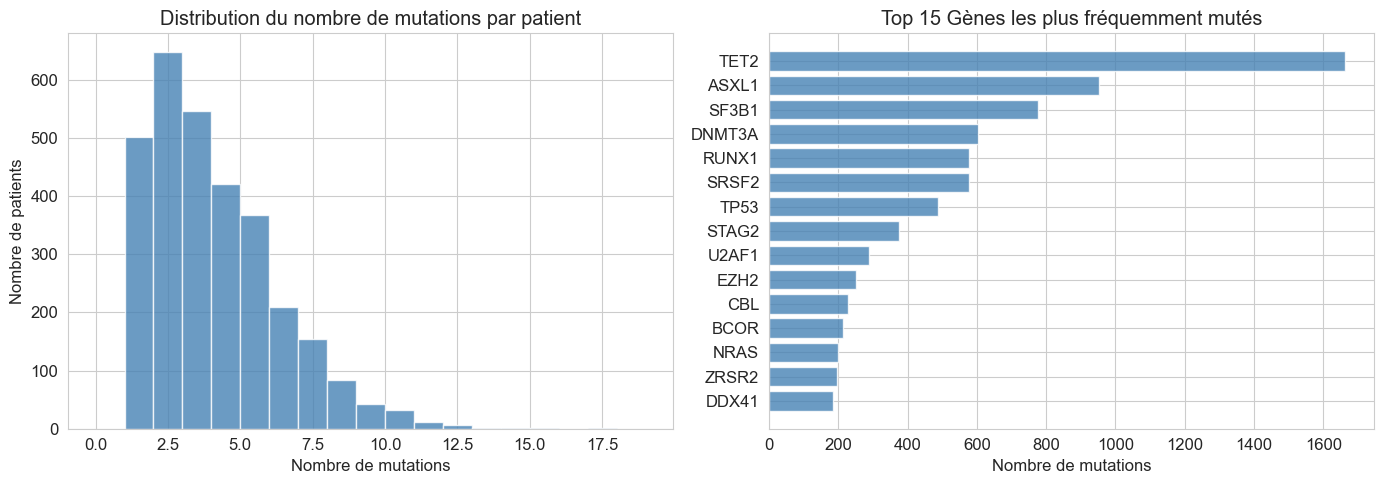

Nombre médian de mutations par patient : 3
Patients sans mutation détectée : 297


In [12]:
#  Nombre de mutations par patient 
mut_counts = molecular_train.groupby('ID').size().reset_index(name='n_mutations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du nombre de mutations
axes[0].hist(mut_counts['n_mutations'], bins=range(0, 20), color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Nombre de mutations')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_title('Distribution du nombre de mutations par patient')

# Top 15 gènes les plus fréquemment mutés
gene_counts = molecular_train['GENE'].value_counts().head(15)
axes[1].barh(gene_counts.index[::-1], gene_counts.values[::-1], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Nombre de mutations')
axes[1].set_title('Top 15 Gènes les plus fréquemment mutés')

plt.tight_layout()
plt.show()

print(f"Nombre médian de mutations par patient : {mut_counts['n_mutations'].median():.0f}")
print(f"Patients sans mutation détectée : {len(clinical_train) - len(mut_counts)}")

In [13]:
#  Types d'effets des mutations 
effect_counts = molecular_train['EFFECT'].value_counts()
print("Répartition des types d'effets des mutations :")
print(effect_counts)
print(f"\nProportion de mutations non-synonymes : {(molecular_train['EFFECT']=='non_synonymous_codon').mean()*100:.1f}%")

Répartition des types d'effets des mutations :
EFFECT
non_synonymous_codon            5471
frameshift_variant              2877
stop_gained                     1673
splice_site_variant              512
inframe_codon_loss               168
PTD                               89
inframe_codon_gain                55
ITD                               26
initiator_codon_change            24
2KB_upstream_variant              12
complex_change_in_transcript      11
3_prime_UTR_variant                5
inframe_variant                    4
stop_lost                          4
synonymous_codon                   3
stop_retained_variant              1
Name: count, dtype: int64

Proportion de mutations non-synonymes : 50.0%


**Observations moléculaires :**
- Les gènes les plus fréquemment mutés sont `TET2`, `ASXL1`, `SF3B1`, `DNMT3A`, `RUNX1`, `SRSF2`, et `TP53`. Ces gènes sont bien connus dans la littérature comme étant des **drivers** de la leucémie myéloïde.
- `TP53` est particulièrement important car ses mutations sont associées à un **pronostic très défavorable**.
- La moitié des mutations sont de type `non_synonymous_codon` (changement d'acide aminé), ce qui signifie un impact fonctionnel potentiel sur la protéine.

### 3.6 Analyse du Caryotype (CYTOGENETICS)

La variable `CYTOGENETICS` est un champ textuel décrivant les anomalies chromosomiques. Nous allons en extraire des informations structurées.

In [14]:
#  Analyse basique de la cytogénétique 
cyto = clinical_train['CYTOGENETICS'].dropna()

# Détecter les caryotypes normaux
is_normal = cyto.str.lower().str.contains(r'^\s*(normal|46,x[xy]\[?\d*\]?\s*$)', regex=True, na=False)
# Approche plus robuste : caryotype normal si contient "Normal" ou est de la forme "46,XX[20]" / "46,XY[20]"
is_normal_v2 = cyto.str.lower().str.match(r'^\s*(normal|46,x[xy](\[\d+\])?)\s*$', na=False)

print(f"Caryotypes normaux : {is_normal_v2.sum()} ({is_normal_v2.mean()*100:.1f}%)")
print(f"Caryotypes anormaux : {(~is_normal_v2).sum()} ({(~is_normal_v2).mean()*100:.1f}%)")

# Exemples de caryotypes complexes
print("\nExemples de caryotypes anormaux :")
for ex in cyto[~is_normal_v2].head(5):
    print(f"  {ex}")

Caryotypes normaux : 1689 (57.5%)
Caryotypes anormaux : 1247 (42.5%)

Exemples de caryotypes anormaux :
  46,xy,del(20)(q12)[2]/46,xy[18]
  46,xy,t(3;3)(q25;q27)[8]/46,xy[12]
  46,xy,del(3)(q26q27)[15]/46,xy[5]
  46,xx,t(3;9)(p13;q22)[10]/46,xx[10]
  45,xx,del(5)(q13q33),inc[2]/46,xx[2]


## 4. Feature Engineering

Le feature engineering est une étape cruciale en Machine Learning. Nous allons construire des variables explicatives à partir des données brutes. L'idée est de transformer l'information disponible en un format exploitable par nos modèles.

### 4.1 Features Cliniques

Les variables cliniques numériques (`BM_BLAST`, `WBC`, `ANC`, `MONOCYTES`, `HB`, `PLT`) seront utilisées directement après imputation des valeurs manquantes par la **médiane** (robuste aux outliers).

### 4.2 Features Cytogénétiques

De la variable textuelle `CYTOGENETICS`, nous extrayons :
- `is_normal_karyotype` : indicateur binaire (caryotype normal vs anormal)
- `n_abnormalities` : nombre d'anomalies détectées (complexité du caryotype)

### 4.3 Features Moléculaires

Des données moléculaires, nous extrayons pour chaque patient :
- `n_mutations` : nombre total de mutations somatiques
- `mean_vaf` : VAF moyenne (charge mutationnelle moyenne)
- `has_TP53` , `has_TET2`, `has_ASXL1`, etc. : indicateurs de mutation dans les gènes pronostiques clés

In [15]:
def build_features(clinical_df, molecular_df):
    """
    Construit le dataframe de features à partir des données cliniques et moléculaires.
    
    Parameters
    ----------
    clinical_df : pd.DataFrame
        Données cliniques (1 ligne par patient)
    molecular_df : pd.DataFrame
        Données moléculaires (1 ligne par mutation)
    
    Returns
    -------
    pd.DataFrame
        DataFrame indexé par ID avec toutes les features
    """
    df = clinical_df.copy()
    
    # --- Features Cliniques (déjà numériques) ---
    num_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
    
    # --- Features Cytogénétiques ---
    cyto = df['CYTOGENETICS'].fillna('')
    # Caryotype normal : "Normal", "46,XX[20]", "46,XY", etc.
    df['is_normal_karyotype'] = cyto.str.lower().str.match(
        r'^\s*(normal|46,x[xy](\[\d+\])?)\s*$', na=False
    ).astype(int)
    
    # Nombre d'anomalies : on compte les termes typiques (del, t, inv, +, -)
    df['n_abnormalities'] = (
        cyto.str.count(r'(del|inv|dup|add|der|ins|\+\d|\-\d|t\()')
    )
    
    # --- Features Moléculaires ---
    # Nombre de mutations par patient
    mut_count = molecular_df.groupby('ID').size().reset_index(name='n_mutations')
    
    # VAF moyenne par patient
    vaf_mean = molecular_df.groupby('ID')['VAF'].mean().reset_index(name='mean_vaf')
    
    # Présence de mutations dans les gènes pronostiques clés
    key_genes = ['TP53', 'TET2', 'ASXL1', 'RUNX1', 'SF3B1', 'SRSF2', 'DNMT3A', 'EZH2']
    gene_features = {}
    for gene in key_genes:
        patients_with_gene = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        gene_features[f'has_{gene}'] = clinical_df['ID'].isin(patients_with_gene).astype(int)
    gene_df = pd.DataFrame(gene_features, index=clinical_df.index)
    
    # Nombre de gènes distincts mutés
    n_genes = molecular_df.groupby('ID')['GENE'].nunique().reset_index(name='n_genes_mutated')
    
    # Fusionner
    df = df.merge(mut_count, on='ID', how='left')
    df = df.merge(vaf_mean, on='ID', how='left')
    df = df.merge(n_genes, on='ID', how='left')
    df = pd.concat([df, gene_df], axis=1)
    
    # Patients sans mutation : remplir par 0
    df['n_mutations'] = df['n_mutations'].fillna(0)
    df['mean_vaf'] = df['mean_vaf'].fillna(0)
    df['n_genes_mutated'] = df['n_genes_mutated'].fillna(0)
    
    return df

#  Appliquer le feature engineering 
train_features = build_features(clinical_train, molecular_train)
test_features = build_features(clinical_test, molecular_test)

print(f"Dimensions du jeu d'entraînement : {train_features.shape}")
print(f"Dimensions du jeu de test : {test_features.shape}")
print(f"\nColonnes créées :")
print(train_features.columns.tolist())

Dimensions du jeu d'entraînement : (3323, 22)
Dimensions du jeu de test : (1193, 22)

Colonnes créées :
['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS', 'is_normal_karyotype', 'n_abnormalities', 'n_mutations', 'mean_vaf', 'n_genes_mutated', 'has_TP53', 'has_TET2', 'has_ASXL1', 'has_RUNX1', 'has_SF3B1', 'has_SRSF2', 'has_DNMT3A', 'has_EZH2']


In [16]:
#  Définir les features finales 
feature_cols = [
    # Cliniques
    'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT',
    # Cytogénétiques
    'is_normal_karyotype', 'n_abnormalities',
    # Moléculaires
    'n_mutations', 'mean_vaf', 'n_genes_mutated',
    'has_TP53', 'has_TET2', 'has_ASXL1', 'has_RUNX1',
    'has_SF3B1', 'has_SRSF2', 'has_DNMT3A', 'has_EZH2'
]

print(f"Nombre total de features : {len(feature_cols)}")
print(f"\nAperçu des features :")
train_features[feature_cols].describe().round(2)

Nombre total de features : 19

Aperçu des features :


,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_normal_karyotype,n_abnormalities,n_mutations,mean_vaf,n_genes_mutated,has_TP53,has_TET2,has_ASXL1,has_RUNX1,has_SF3B1,has_SRSF2,has_DNMT3A,has_EZH2
count,3214.00,3051.00,3130.00,2722.00,3213.00,3199.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00,3323.00
mean,5.98,6.54,3.26,0.96,9.89,167.05,0.51,0.99,3.29,0.28,2.83,0.11,0.31,0.27,0.14,0.22,0.17,0.16,0.07
std,7.62,10.25,5.24,2.67,2.04,149.48,0.50,2.60,2.36,0.18,1.93,0.32,0.46,0.44,0.35,0.42,0.38,0.37,0.25
min,0.00,0.20,0.00,0.00,4.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,2.70,1.00,0.15,8.50,65.50,0.00,0.00,2.00,0.16,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,3.00,4.10,2.00,0.37,9.70,123.00,1.00,0.00,3.00,0.28,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,8.00,6.66,3.69,0.78,11.20,229.50,1.00,1.00,5.00,0.40,4.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
max,91.00,154.40,109.62,44.20,16.60,1451.00,1.00,25.00,17.00,0.99,11.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 5. Préparation des Données pour la Modélisation

### 5.1 Construction de la variable cible structurée

Pour les modèles de survie (Cox, Random Survival Forest), la variable cible doit être un **tableau structuré** contenant à la fois l'indicateur d'événement (booléen) et le temps de survie.

In [17]:
#  Préparer la variable cible au format survival 
# Fusionner features et cible
train_df = train_features.merge(target_train, on='ID')
train_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)
train_df['OS_STATUS'] = train_df['OS_STATUS'].astype(bool)

# Créer la variable cible structurée pour scikit-survival
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', train_df)

# Matrice de features
X_all = train_df[feature_cols].copy()

print(f"Taille du jeu de données : {X_all.shape}")
print(f"\nType de la variable cible : {y_surv.dtype}")
print(f"Premiers éléments : {y_surv[:5]}")

Taille du jeu de données : (3173, 19)

Type de la variable cible : [('OS_STATUS', '?'), ('OS_YEARS', '<f8')]
Premiers éléments : [( True, 1.11506849) (False, 4.92876712) (False, 2.04383562)
 ( True, 2.47671233) (False, 3.14520548)]


In [18]:
#  Split train / validation (70% / 30%) 
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_surv, test_size=0.3, random_state=42
)

print(f"Train : {X_train.shape[0]} patients")
print(f"Validation : {X_val.shape[0]} patients")

Train : 2221 patients
Validation : 952 patients


In [19]:
#  Imputation des valeurs manquantes par la médiane 
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val), columns=feature_cols, index=X_val.index
)

print(f"Valeurs manquantes après imputation (train) : {X_train_imp.isnull().sum().sum()}")
print(f"Valeurs manquantes après imputation (val) : {X_val_imp.isnull().sum().sum()}")

Valeurs manquantes après imputation (train) : 0
Valeurs manquantes après imputation (val) : 0


## 6. Modèle de Référence : Régression de Cox

### Formulation Mathématique

Le modèle de Cox à risques proportionnels (*Cox Proportional Hazards*, 1972) est un modèle **semi-paramétrique** de survie. Il modélise la **fonction de risque instantané** (*hazard function*) :

$$h(t \mid \mathbf{x}) = h_0(t) \cdot \exp\left(\boldsymbol{\beta}^\top \mathbf{x}\right) = h_0(t) \cdot \exp\left(\sum_{j=1}^{p} \beta_j x_j\right)$$

où :
- $h(t \mid \mathbf{x})$ est le risque instantané de décès au temps $t$ pour un patient de covariables $\mathbf{x}$
- $h_0(t)$ est le **risque de base** (*baseline hazard*), commun à tous les patients, non paramétré
- $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_p)^\top$ sont les coefficients de régression à estimer
- $\mathbf{x} = (x_1, \ldots, x_p)^\top$ sont les covariables (features) du patient

**Hypothèse clé ; Risques Proportionnels :** Le rapport des risques entre deux patients $i$ et $j$ est **constant dans le temps** :

$$\frac{h(t \mid \mathbf{x}_i)}{h(t \mid \mathbf{x}_j)} = \frac{h_0(t) \exp(\boldsymbol{\beta}^\top \mathbf{x}_i)}{h_0(t) \exp(\boldsymbol{\beta}^\top \mathbf{x}_j)} = \exp\left(\boldsymbol{\beta}^\top (\mathbf{x}_i - \mathbf{x}_j)\right)$$

**Estimation des paramètres :** Les coefficients $\boldsymbol{\beta}$ sont estimés par maximisation de la **vraisemblance partielle** (*partial likelihood*) de Cox :

$$\mathcal{L}(\boldsymbol{\beta}) = \prod_{i : \delta_i = 1} \frac{\exp(\boldsymbol{\beta}^\top \mathbf{x}_i)}{\sum_{j \in \mathcal{R}(t_i)} \exp(\boldsymbol{\beta}^\top \mathbf{x}_j)}$$

où $\mathcal{R}(t_i)$ est l'ensemble des patients encore à risque au temps $t_i$ (*risk set*) et $\delta_i = 1$ si le patient $i$ a subi l'événement.

**Score de risque :** La prédiction du modèle de Cox est le **risque linéaire** $\hat{R}_i = \boldsymbol{\hat{\beta}}^\top \mathbf{x}_i$. Un score plus élevé correspond à un risque de décès plus élevé.

**Avantage pour notre problème :** Le modèle de Cox gère naturellement la censure à droite via la vraisemblance partielle ; les patients censurés contribuent au *risk set* mais pas aux termes du numérateur.

In [20]:
#  Entraînement du modèle de Cox 
cox_model = CoxPHSurvivalAnalysis(alpha=0.01)  # alpha = régularisation L2 légère
cox_model.fit(X_train_imp, y_train)

# Prédictions (score de risque linéaire)
risk_train_cox = cox_model.predict(X_train_imp)
risk_val_cox = cox_model.predict(X_val_imp)

# Évaluation : IPCW C-index (tronqué à 7 ans)
cindex_train_cox = concordance_index_ipcw(y_train, y_train, risk_train_cox, tau=7)[0]
cindex_val_cox = concordance_index_ipcw(y_train, y_val, risk_val_cox, tau=7)[0]

print(f" Modèle de Cox (Référence) ")
print(f"IPCW C-index (train) : {cindex_train_cox:.4f}")
print(f"IPCW C-index (validation) : {cindex_val_cox:.4f}")
print(f"Écart train-val : {cindex_train_cox - cindex_val_cox:.4f}")

 Modèle de Cox (Référence) 
IPCW C-index (train) : 0.7227
IPCW C-index (validation) : 0.7057
Écart train-val : 0.0171


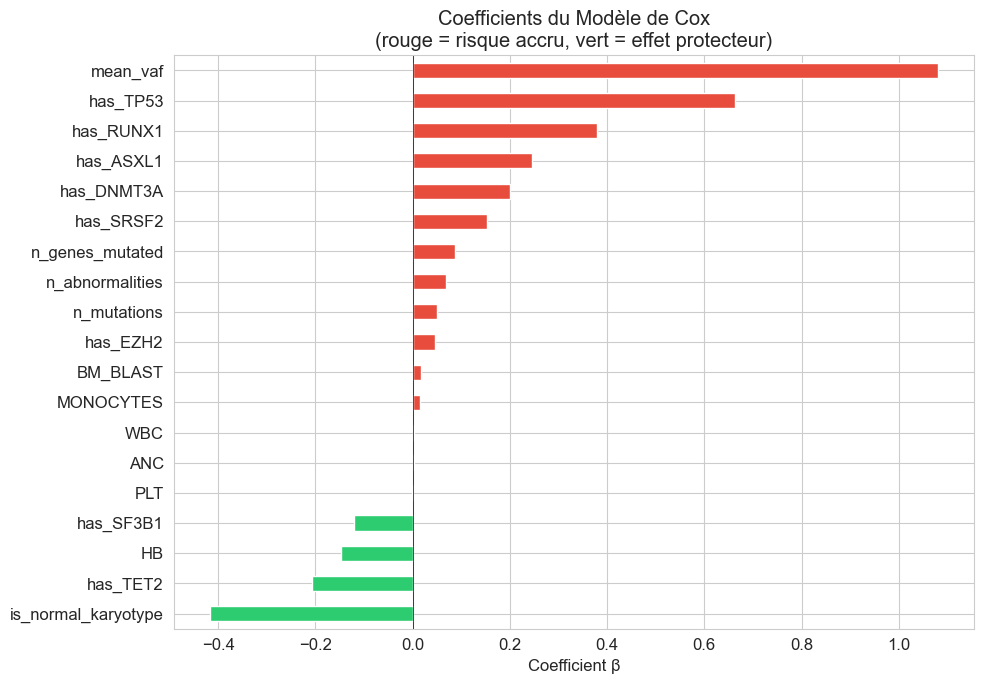


Interprétation : exp(β) donne le Hazard Ratio (HR)
Un HR > 1 signifie un risque accru, HR < 1 un effet protecteur.

  is_normal_karyotype       : β = -0.4167, HR = 0.6592 (risque faible)
  has_TET2                  : β = -0.2062, HR = 0.8137 (risque faible)
  HB                        : β = -0.1476, HR = 0.8627 (risque faible)
  has_SF3B1                 : β = -0.1213, HR = 0.8858 (risque faible)
  PLT                       : β = -0.0015, HR = 0.9985 (risque faible)
  ANC                       : β = +0.0032, HR = 1.0032 (risque elevé)
  WBC                       : β = +0.0036, HR = 1.0036 (risque elevé)
  MONOCYTES                 : β = +0.0150, HR = 1.0151 (risque elevé)
  BM_BLAST                  : β = +0.0180, HR = 1.0182 (risque elevé)
  has_EZH2                  : β = +0.0471, HR = 1.0482 (risque elevé)
  n_mutations               : β = +0.0500, HR = 1.0513 (risque elevé)
  n_abnormalities           : β = +0.0693, HR = 1.0718 (risque elevé)
  n_genes_mutated           : β = +0.0

In [21]:
#  Coefficients du modèle de Cox 
cox_coefs = pd.Series(cox_model.coef_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in cox_coefs.values]
cox_coefs.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.set_xlabel('Coefficient β')
ax.set_title('Coefficients du Modèle de Cox\n(rouge = risque accru, vert = effet protecteur)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nInterprétation : exp(β) donne le Hazard Ratio (HR)")
print("Un HR > 1 signifie un risque accru, HR < 1 un effet protecteur.")
print()
for feat, coef in cox_coefs.items():
    hr = np.exp(coef)
    direction = "risque elevé" if coef > 0 else "risque faible"
    print(f"  {feat:25s} : β = {coef:+.4f}, HR = {hr:.4f} ({direction})")

**Interprétation du modèle de Cox :**
- Les coefficients $\beta$ positifs indiquent un facteur de **mauvais pronostic** (augmentation du risque).
- Les coefficients négatifs indiquent un facteur **protecteur**.
- Le *Hazard Ratio* (HR) = $\exp(\beta)$ donne le facteur multiplicatif du risque. Par exemple, HR = 2 signifie un risque doublé.

Ce modèle de référence servira de base de comparaison pour les modèles suivants.

## 7. Approche Non Supervisée : Clustering K-Means

### Objectif

L'analyse non supervisée permet de découvrir des **profils de patients** sans utiliser la variable cible. L'idée est que des patients présentant des caractéristiques cliniques et moléculaires similaires pourraient avoir des trajectoires de survie comparables.

Nous utilisons **K-Means**, un algorithme de clustering par partition.

### Formulation Mathématique de K-Means

L'algorithme K-Means cherche à partitionner $n$ observations $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$ en $K$ clusters $\{C_1, \ldots, C_K\}$ de manière à **minimiser l'inertie intra-cluster** (somme des distances au carré au centroïde) :

$$\min_{C_1, \ldots, C_K} \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$

où $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i$ est le centroïde du cluster $k$.

**Algorithme itératif :**
1. Initialiser $K$ centroïdes aléatoirement
2. **Affectation :** Assigner chaque point au centroïde le plus proche : $C_k = \{\mathbf{x}_i : \|\mathbf{x}_i - \boldsymbol{\mu}_k\| \leq \|\mathbf{x}_i - \boldsymbol{\mu}_l\|, \forall l\}$
3. **Mise à jour :** Recalculer les centroïdes : $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} \mathbf{x}_i$
4. Répéter 2-3 jusqu'à convergence

**Score de Silhouette :** Pour choisir le nombre optimal de clusters $K$, nous utilisons le **coefficient de silhouette**. Pour chaque point $i$ :

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

où $a(i)$ est la distance moyenne intra-cluster et $b(i)$ la distance moyenne au cluster le plus proche. $s(i) \in [-1, 1]$, un score proche de 1 indique un bon clustering.

### Application

**Important :** Les données doivent être **standardisées** avant le clustering, car K-Means est sensible à l'échelle des variables.

  File "C:\Users\salim\env-craft\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


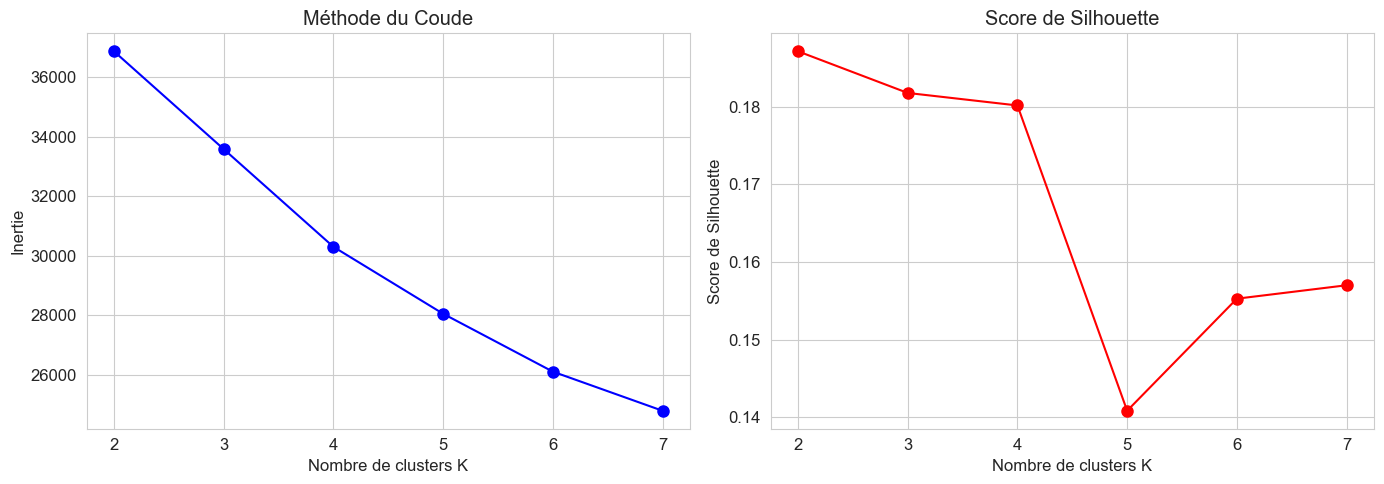

Meilleur K selon le score de silhouette : 2
Score de silhouette correspondant : 0.1872


In [22]:
#  Standardisation des features pour le clustering 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)

#  Recherche du nombre optimal de clusters 
K_range = range(2, 8)
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Méthode du coude
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude')

# Score de silhouette
axes[1].plot(list(K_range), silhouettes, 'ro-', markersize=8)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Meilleur K selon le score de silhouette : {best_k}")
print(f"Score de silhouette correspondant : {max(silhouettes):.4f}")

In [23]:
#  Clustering avec K optimal 
K_CHOSEN = 2  
# k = 3 donne des résultats plus interprétables, 
# mais nous avons choisit le k qui donne le meilleur score

# On a aussi testé K=4 mais les clusters devenaient peu interprétables

kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_scaled)

# Ajouter les clusters aux données pour analyse
X_train_with_cluster = X_train_imp.copy()
X_train_with_cluster['cluster'] = train_clusters

# Assigner les clusters au jeu de validation
X_val_scaled = scaler.transform(X_val_imp)
val_clusters = kmeans_final.predict(X_val_scaled)

print(f"Répartition des patients par cluster (train) :")
print(pd.Series(train_clusters).value_counts().sort_index())

Répartition des patients par cluster (train) :
0     698
1    1523
Name: count, dtype: int64


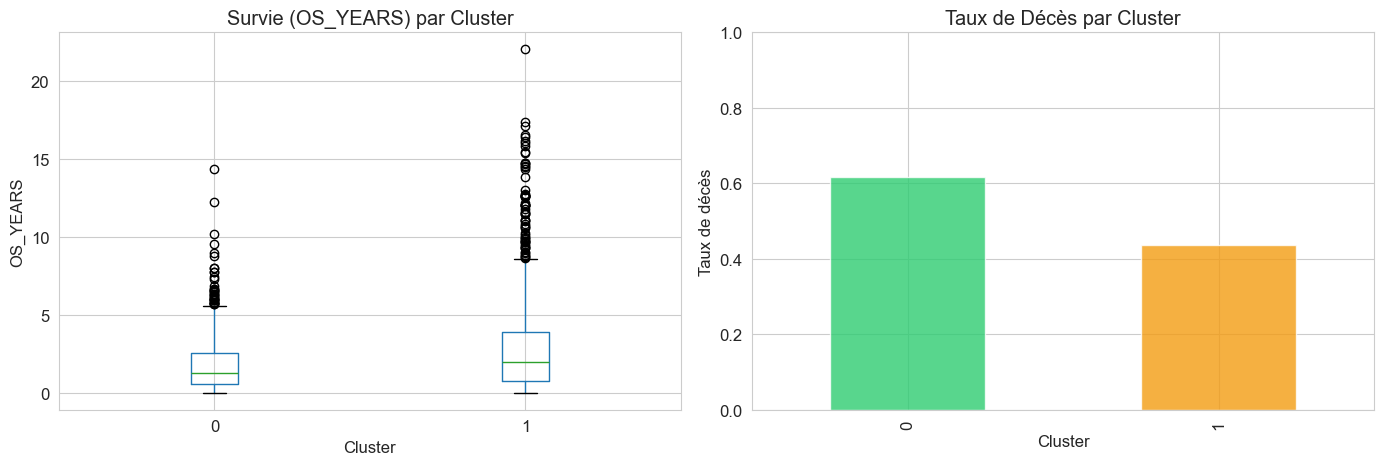

Cluster 0 : 698 patients, survie médiane = 1.28 ans, taux de décès = 61.7%
Cluster 1 : 1523 patients, survie médiane = 1.94 ans, taux de décès = 43.7%


In [24]:
#  Analyse de la survie par cluster 
# Fusionner clusters avec la cible
cluster_surv = pd.DataFrame({
    'cluster': train_clusters,
    'OS_STATUS': [y[0] for y in y_train],
    'OS_YEARS': [y[1] for y in y_train]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de la survie par cluster
cluster_surv.boxplot(column='OS_YEARS', by='cluster', ax=axes[0])
axes[0].set_title('Survie (OS_YEARS) par Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('OS_YEARS')
plt.sca(axes[0])
plt.title('Survie (OS_YEARS) par Cluster')

# Taux de décès par cluster
death_rate = cluster_surv.groupby('cluster')['OS_STATUS'].mean()
death_rate.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'][:K_CHOSEN],
                edgecolor='white', alpha=0.8)
axes[1].set_title('Taux de Décès par Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Taux de décès')
axes[1].set_ylim(0, 1)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Statistiques par cluster
for c in range(K_CHOSEN):
    subset = cluster_surv[cluster_surv['cluster'] == c]
    print(f"Cluster {c} : {len(subset)} patients, "
          f"survie médiane = {subset['OS_YEARS'].median():.2f} ans, "
          f"taux de décès = {subset['OS_STATUS'].mean()*100:.1f}%")

In [25]:
#  Profil des clusters : moyennes des features par cluster 
cluster_profiles = X_train_with_cluster.groupby('cluster')[feature_cols].mean()
print("Profil moyen des clusters :")
cluster_profiles.T.round(2)

Profil moyen des clusters :


cluster,0,1
BM_BLAST,7.78,5.23
WBC,10.21,4.65
ANC,4.83,2.48
MONOCYTES,1.75,0.45
HB,9.88,9.80
PLT,134.18,180.71
is_normal_karyotype,0.61,0.46
n_abnormalities,0.37,1.26
n_mutations,5.86,2.18
mean_vaf,0.34,0.26


### Utilisation des Clusters comme Feature

Les clusters identifiés par K-Means capturent des profils de patients distincts. Nous utilisons l'appartenance au cluster comme **feature catégorielle supplémentaire** dans nos modèles supervisés. L'hypothèse est que cette information synthétique peut capturer des interactions non-linéaires entre les variables originales.

In [26]:
#  Ajouter le cluster comme feature (one-hot encoding) 
def add_cluster_features(X_df, cluster_labels, K):
    """Ajoute les features de cluster en one-hot encoding."""
    X_new = X_df.copy()
    for k in range(K):
        X_new[f'cluster_{k}'] = (cluster_labels == k).astype(int)
    return X_new

X_train_clust = add_cluster_features(X_train_imp, train_clusters, K_CHOSEN)
X_val_clust = add_cluster_features(X_val_imp, val_clusters, K_CHOSEN)

feature_cols_clust = feature_cols + [f'cluster_{k}' for k in range(K_CHOSEN)]
print(f"Nombre de features avec clusters : {len(feature_cols_clust)}")

Nombre de features avec clusters : 21


In [27]:
#  Cox avec features de clustering 
cox_clust = CoxPHSurvivalAnalysis(alpha=0.01)
cox_clust.fit(X_train_clust[feature_cols_clust], y_train)

risk_train_cox_clust = cox_clust.predict(X_train_clust[feature_cols_clust])
risk_val_cox_clust = cox_clust.predict(X_val_clust[feature_cols_clust])

cindex_train_cox_clust = concordance_index_ipcw(y_train, y_train, risk_train_cox_clust, tau=7)[0]
cindex_val_cox_clust = concordance_index_ipcw(y_train, y_val, risk_val_cox_clust, tau=7)[0]

print(f" Cox + Clusters K-Means ")
print(f"IPCW C-index (train) : {cindex_train_cox_clust:.4f}")
print(f"IPCW C-index (validation) : {cindex_val_cox_clust:.4f}")
print(f"\nComparaison avec Cox simple :")
print(f"  Cox simple (val) : {cindex_val_cox:.4f}")
print(f"  Cox + clusters (val) : {cindex_val_cox_clust:.4f}")
print(f"  Δ : {cindex_val_cox_clust - cindex_val_cox:+.4f}")

 Cox + Clusters K-Means 
IPCW C-index (train) : 0.7227
IPCW C-index (validation) : 0.7058

Comparaison avec Cox simple :
  Cox simple (val) : 0.7057
  Cox + clusters (val) : 0.7058
  Δ : +0.0001


## 8. Modèle Supervisé Ensembliste : Random Survival Forest

### Formulation Mathématique

La **Random Survival Forest** (RSF, Ishwaran et al., 2008) est une extension des forêts aléatoires (*Random Forests* de Breiman) adaptée à l'analyse de survie.

**Principe des forêts aléatoires :** Un ensemble de $B$ arbres de décision sont entraînés sur des sous-échantillons bootstrap des données. À chaque nœud de chaque arbre, seul un sous-ensemble aléatoire de $m$ features (typiquement $m = \lfloor\sqrt{p}\rfloor$) est considéré pour la meilleure coupure. La prédiction finale est la **moyenne** des prédictions individuelles.

**Adaptation à la survie :** Dans une RSF, le critère de coupure à chaque nœud est basé sur le **log-rank test**, qui compare les courbes de survie des deux groupes créés par la coupure. Le *log-rank statistic* pour une coupure $c$ sur la variable $j$ est :

$$\chi^2 = \frac{\left(\sum_{k} d_{1k} - \sum_{k} e_{1k}\right)^2}{\sum_{k} v_k}$$

où $d_{1k}$ est le nombre de décès dans le groupe 1 au temps $t_k$, $e_{1k}$ le nombre attendu sous $H_0$ (pas de différence), et $v_k$ la variance.

**Fonction de risque cumulée de Nelson-Aalen :** Chaque feuille $l$ de l'arbre estime la **fonction de risque cumulée** pour les patients qui y tombent :

$$\hat{H}_l(t) = \sum_{t_k \leq t} \frac{d_{lk}}{n_{lk}}$$

où $d_{lk}$ est le nombre de décès et $n_{lk}$ le nombre de patients à risque dans la feuille $l$ au temps $t_k$.

**Prédiction ensembliste :** La prédiction finale est la moyenne des fonctions de risque cumulées sur tous les arbres :

$$\hat{H}(t \mid \mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{H}_b(t \mid \mathbf{x})$$

Le score de risque utilisé pour le ranking est le risque cumulé total $\hat{H}(\tau \mid \mathbf{x})$.

**Avantages :**
- Capture les **interactions non-linéaires** entre variables
- Robuste au sur-apprentissage grâce au bagging
- Gère naturellement la censure via le log-rank
- Pas besoin de standardiser les données

In [28]:
#  Random Survival Forest ; Grid Search 
# On teste quelques combinaisons d'hyperparamètres
# (grid réduit pour limiter le temps de calcul)

from itertools import product

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [10, 20],
}

best_score = -1
best_params = {}
results_rsf = []

print("Grid Search pour la Random Survival Forest...")
print("-" * 60)

for n_est, depth, min_leaf in product(
    param_grid['n_estimators'], param_grid['max_depth'], param_grid['min_samples_leaf']
):
    rsf = RandomSurvivalForest(
        n_estimators=n_est,
        max_depth=depth,
        min_samples_leaf=min_leaf,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_train_imp, y_train)
    
    risk_val = rsf.predict(X_val_imp)
    score = concordance_index_ipcw(y_train, y_val, risk_val, tau=7)[0]
    
    results_rsf.append({
        'n_estimators': n_est, 'max_depth': depth,
        'min_samples_leaf': min_leaf, 'cindex_val': score
    })
    
    if score > best_score:
        best_score = score
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_leaf': min_leaf}
    
    print(f"  n_est={n_est:3d}, depth={str(depth):5s}, min_leaf={min_leaf:2d} → C-index(val) = {score:.4f}")

print(f"\nMeilleurs paramètres : {best_params}")
print(f"Meilleur IPCW C-index (val) : {best_score:.4f}")

Grid Search pour la Random Survival Forest...
------------------------------------------------------------
  n_est=100, depth=5    , min_leaf=10 → C-index(val) = 0.7095
  n_est=100, depth=5    , min_leaf=20 → C-index(val) = 0.7094
  n_est=100, depth=10   , min_leaf=10 → C-index(val) = 0.7140
  n_est=100, depth=10   , min_leaf=20 → C-index(val) = 0.7119
  n_est=100, depth=None , min_leaf=10 → C-index(val) = 0.7136
  n_est=100, depth=None , min_leaf=20 → C-index(val) = 0.7143
  n_est=200, depth=5    , min_leaf=10 → C-index(val) = 0.7113
  n_est=200, depth=5    , min_leaf=20 → C-index(val) = 0.7104
  n_est=200, depth=10   , min_leaf=10 → C-index(val) = 0.7150
  n_est=200, depth=10   , min_leaf=20 → C-index(val) = 0.7137
  n_est=200, depth=None , min_leaf=10 → C-index(val) = 0.7143
  n_est=200, depth=None , min_leaf=20 → C-index(val) = 0.7146

Meilleurs paramètres : {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 10}
Meilleur IPCW C-index (val) : 0.7150


In [29]:
#  Entraîner le modèle RSF final avec les meilleurs paramètres 
rsf_best = RandomSurvivalForest(
    **best_params,
    random_state=42,
    n_jobs=-1
)
rsf_best.fit(X_train_imp, y_train)

risk_train_rsf = rsf_best.predict(X_train_imp)
risk_val_rsf = rsf_best.predict(X_val_imp)

cindex_train_rsf = concordance_index_ipcw(y_train, y_train, risk_train_rsf, tau=7)[0]
cindex_val_rsf = concordance_index_ipcw(y_train, y_val, risk_val_rsf, tau=7)[0]

print(f" Random Survival Forest (meilleurs paramètres) ")
print(f"IPCW C-index (train) : {cindex_train_rsf:.4f}")
print(f"IPCW C-index (validation) : {cindex_val_rsf:.4f}")
print(f"Écart train-val : {cindex_train_rsf - cindex_val_rsf:.4f}")

 Random Survival Forest (meilleurs paramètres) 
IPCW C-index (train) : 0.7895
IPCW C-index (validation) : 0.7150
Écart train-val : 0.0745


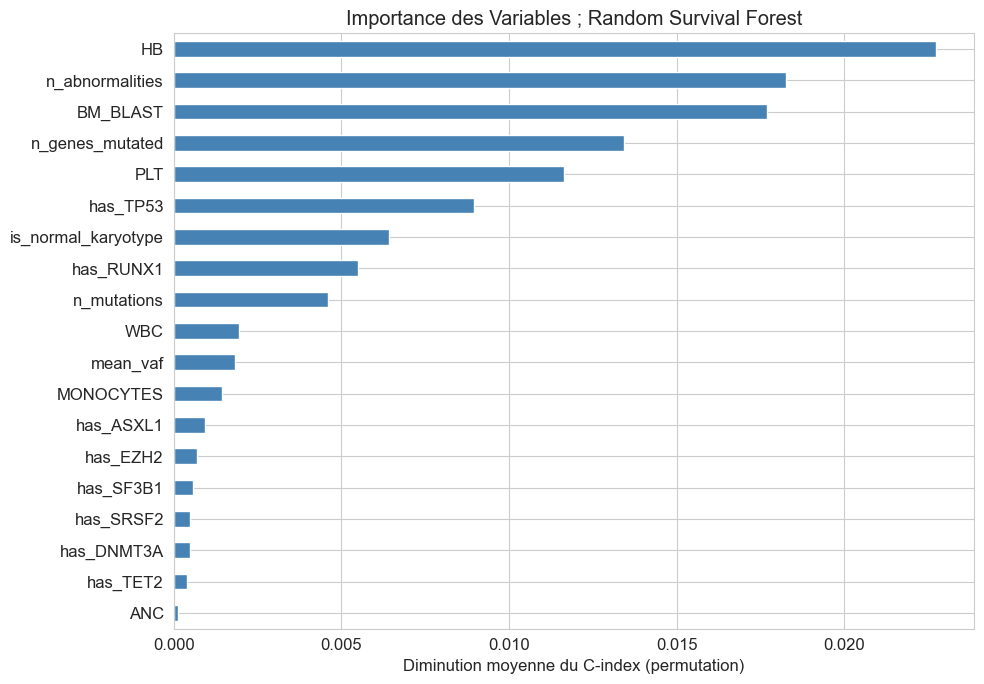

In [30]:
#  Feature Importance (permutation-based via sklearn) 
from sklearn.inspection import permutation_importance

# On définit un scorer compatible avec scikit-survival
def cindex_scorer(estimator, X, y):
    risk = estimator.predict(X)
    try:
        return concordance_index_ipcw(y_train, y, risk, tau=7)[0]
    except:
        return concordance_index_censored(y['OS_STATUS'], y['OS_YEARS'], risk)[0]

perm_result = permutation_importance(
    rsf_best, X_val_imp, y_val,
    scoring=cindex_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm_result.importances_mean, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue', ax=ax, edgecolor='white')
ax.set_xlabel('Diminution moyenne du C-index (permutation)')
ax.set_title('Importance des Variables ; Random Survival Forest')
plt.tight_layout()
plt.show()

**Analyse de l'importance des variables :**
- Les variables les plus importantes pour la RSF permettent d'identifier les **facteurs pronostiques clés** de la maladie.
- La comparaison avec les coefficients de Cox est intéressante : le modèle de Cox capture des effets linéaires tandis que la RSF peut capturer des relations non-linéaires et des interactions.
- La RSF, étant un modèle ensembliste non-linéaire, obtient effectivement un C-index supérieur au modèle de Cox sur la validation, car elle peut modéliser des interactions complexes entre les variables.

## 9. Modèle de Deep Learning : Perceptron Multi-Couches (MLP)

### Formulation Mathématique

Un **Perceptron Multi-Couches** (MLP) est un réseau de neurones dense composé de plusieurs couches de neurones interconnectés. Chaque couche $l$ effectue une transformation affine suivie d'une fonction d'activation non-linéaire :

$$\mathbf{h}^{(l)} = \sigma\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

où :
- $\mathbf{h}^{(l)} \in \mathbb{R}^{d_l}$ est le vecteur d'activations de la couche $l$
- $\mathbf{W}^{(l)} \in \mathbb{R}^{d_l \times d_{l-1}}$ est la matrice de poids
- $\mathbf{b}^{(l)} \in \mathbb{R}^{d_l}$ est le vecteur de biais
- $\sigma$ est la fonction d'activation (ici **ReLU** : $\sigma(z) = \max(0, z)$)

**Architecture :** Input → Dense(64, ReLU) → Dropout → Dense(32, ReLU) → Dropout → Dense(1, linéaire)

La sortie est un **score de risque scalaire** $\hat{R}_i = f_\theta(\mathbf{x}_i)$.

### Fonction de Perte : Perte de Cox Partielle

Pour adapter le MLP à la survie, on utilise la **perte de log-vraisemblance partielle de Cox négative** :

$$\mathcal{L}(\theta) = -\sum_{i: \delta_i = 1} \left[ f_\theta(\mathbf{x}_i) - \log\left(\sum_{j \in \mathcal{R}(t_i)} \exp(f_\theta(\mathbf{x}_j))\right) \right]$$

Cette perte encourage le modèle à assigner des scores de risque plus élevés aux patients qui décèdent plus tôt. Elle gère la censure car seuls les patients ayant subi l'événement ($\delta_i = 1$) contribuent au numérateur.

**Optimisation :** Adam optimizer avec learning rate décroissant et early stopping pour éviter le sur-apprentissage.

In [31]:
#  MLP avec PyTorch pour la survie 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#  Définition du réseau 
class SurvivalMLP(nn.Module):
    """
    Perceptron Multi-Couches pour la prédiction de survie.
    Sortie : score de risque scalaire.
    """
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)

print("Architecture du MLP :")
model_mlp = SurvivalMLP(input_dim=len(feature_cols))
print(model_mlp)
total_params = sum(p.numel() for p in model_mlp.parameters())
print(f"\nNombre total de paramètres : {total_params}")

Architecture du MLP :
SurvivalMLP(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Nombre total de paramètres : 3393


In [32]:
#  Fonction de perte de Cox partielle 
def cox_partial_likelihood_loss(risk_scores, times, events):
    """
    Perte de log-vraisemblance partielle de Cox négative.
    
    Parameters
    ----------
    risk_scores : Tensor de shape (n,)
        Scores de risque prédits par le modèle
    times : Tensor de shape (n,)
        Temps de survie observés
    events : Tensor de shape (n,)
        Indicateurs d'événement (1=décès, 0=censuré)
    
    Returns
    -------
    loss : Tensor scalaire
    """
    # Trier par temps de survie décroissant
    order = torch.argsort(times, descending=True)
    risk_sorted = risk_scores[order]
    events_sorted = events[order]
    
    # Log-sum-exp cumulé (pour la stabilité numérique)
    log_cumsum_exp = torch.logcumsumexp(risk_sorted, dim=0)
    
    # Perte partielle : uniquement les événements non censurés
    loss = -torch.mean((risk_sorted - log_cumsum_exp) * events_sorted)
    return loss

print("Fonction de perte définie.")

Fonction de perte définie.


In [33]:
#  Préparation des données pour PyTorch 
# Standardiser les features
scaler_mlp = StandardScaler()
X_train_nn = scaler_mlp.fit_transform(X_train_imp)
X_val_nn = scaler_mlp.transform(X_val_imp)

# Convertir en tenseurs
X_train_t = torch.FloatTensor(X_train_nn)
X_val_t = torch.FloatTensor(X_val_nn)

# Extraire temps et événements
times_train = torch.FloatTensor([y[1] for y in y_train])
events_train = torch.FloatTensor([float(y[0]) for y in y_train])
times_val = torch.FloatTensor([y[1] for y in y_val])
events_val = torch.FloatTensor([float(y[0]) for y in y_val])

print(f"Tenseurs d'entraînement : X={X_train_t.shape}, times={times_train.shape}")

Tenseurs d'entraînement : X=torch.Size([2221, 19]), times=torch.Size([2221])


In [34]:
#  Entraînement du MLP 
torch.manual_seed(42)

model_mlp = SurvivalMLP(input_dim=len(feature_cols), hidden_dims=[64, 32], dropout=0.3)
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

n_epochs = 200
train_losses = []
val_scores = []
best_val_score = -1
best_epoch = 0
patience = 30
patience_counter = 0

print("Entraînement du MLP...")
print("-" * 50)

for epoch in range(n_epochs):
    # --- Train ---
    model_mlp.train()
    optimizer.zero_grad()
    risk_pred = model_mlp(X_train_t)
    loss = cox_partial_likelihood_loss(risk_pred, times_train, events_train)
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())
    
    # --- Validation (tous les 10 epochs) ---
    if (epoch + 1) % 10 == 0:
        model_mlp.eval()
        with torch.no_grad():
            risk_val_pred = model_mlp(X_val_t).numpy()
        
        try:
            score = concordance_index_ipcw(y_train, y_val, risk_val_pred, tau=7)[0]
        except:
            score = 0.5
        
        val_scores.append((epoch + 1, score))
        
        if score > best_val_score:
            best_val_score = score
            best_epoch = epoch + 1
            best_state = model_mlp.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 10
        
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | C-index(val): {score:.4f}")
    
    if patience_counter >= patience:
        print(f"  Early stopping à l'epoch {epoch+1}")
        break

print(f"\nMeilleur C-index (val) : {best_val_score:.4f} à l'epoch {best_epoch}")

Entraînement du MLP...
--------------------------------------------------
  Epoch  50 | Loss: 3.2670 | C-index(val): 0.7081
  Epoch 100 | Loss: 3.2455 | C-index(val): 0.7150
  Epoch 150 | Loss: 3.2450 | C-index(val): 0.7162
  Early stopping à l'epoch 180

Meilleur C-index (val) : 0.7162 à l'epoch 150


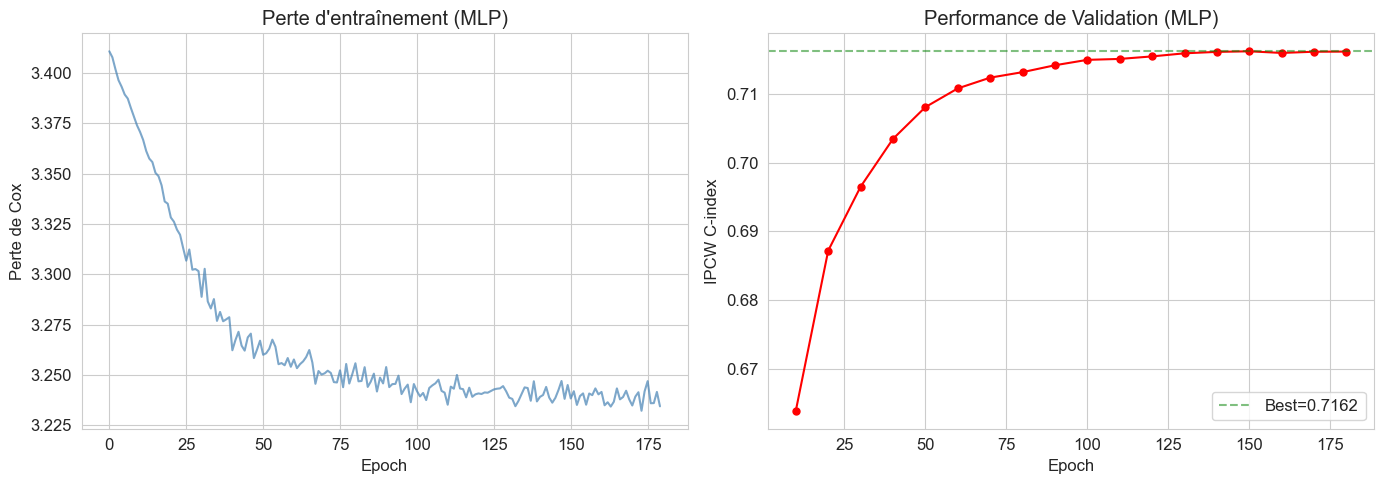

In [35]:
#  Courbe de perte et de performance 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perte d'entraînement
axes[0].plot(train_losses, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perte de Cox')
axes[0].set_title("Perte d'entraînement (MLP)")

# C-index de validation
epochs_eval, scores_eval = zip(*val_scores)
axes[1].plot(epochs_eval, scores_eval, 'ro-', markersize=5)
axes[1].axhline(y=best_val_score, color='green', linestyle='--', alpha=0.5, label=f'Best={best_val_score:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IPCW C-index')
axes[1].set_title('Performance de Validation (MLP)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
#  Évaluation finale du MLP 
model_mlp.load_state_dict(best_state)
model_mlp.eval()

with torch.no_grad():
    risk_train_mlp = model_mlp(X_train_t).numpy()
    risk_val_mlp = model_mlp(X_val_t).numpy()

cindex_train_mlp = concordance_index_ipcw(y_train, y_train, risk_train_mlp, tau=7)[0]
cindex_val_mlp = concordance_index_ipcw(y_train, y_val, risk_val_mlp, tau=7)[0]

print(f" MLP (Deep Learning) ")
print(f"IPCW C-index (train) : {cindex_train_mlp:.4f}")
print(f"IPCW C-index (validation) : {cindex_val_mlp:.4f}")
print(f"Écart train-val : {cindex_train_mlp - cindex_val_mlp:.4f}")

 MLP (Deep Learning) 
IPCW C-index (train) : 0.7350
IPCW C-index (validation) : 0.7162
Écart train-val : 0.0188


## 10. Comparaison des Modèles et Interprétation

### 10.1 Tableau Comparatif

In [37]:
#  Tableau comparatif 
results = pd.DataFrame({
    'Modèle': ['Cox PH (référence)', 'Cox PH + Clusters', 'Random Survival Forest', 'MLP (Deep Learning)'],
    'C-index (train)': [cindex_train_cox, cindex_train_cox_clust, cindex_train_rsf, cindex_train_mlp],
    'C-index (val)': [cindex_val_cox, cindex_val_cox_clust, cindex_val_rsf, cindex_val_mlp],
})
results['Écart train-val'] = results['C-index (train)'] - results['C-index (val)']
results = results.sort_values('C-index (val)', ascending=False)

print("=" * 75)
print("COMPARAISON DES MODÈLES ; IPCW C-index (τ=7 ans)")
print("=" * 75)
print(results.to_string(index=False, float_format='%.4f'))
print("=" * 75)

COMPARAISON DES MODÈLES ; IPCW C-index (τ=7 ans)
                Modèle  C-index (train)  C-index (val)  Écart train-val
   MLP (Deep Learning)           0.7350         0.7162           0.0188
Random Survival Forest           0.7895         0.7150           0.0745
     Cox PH + Clusters           0.7227         0.7058           0.0170
    Cox PH (référence)           0.7227         0.7057           0.0171


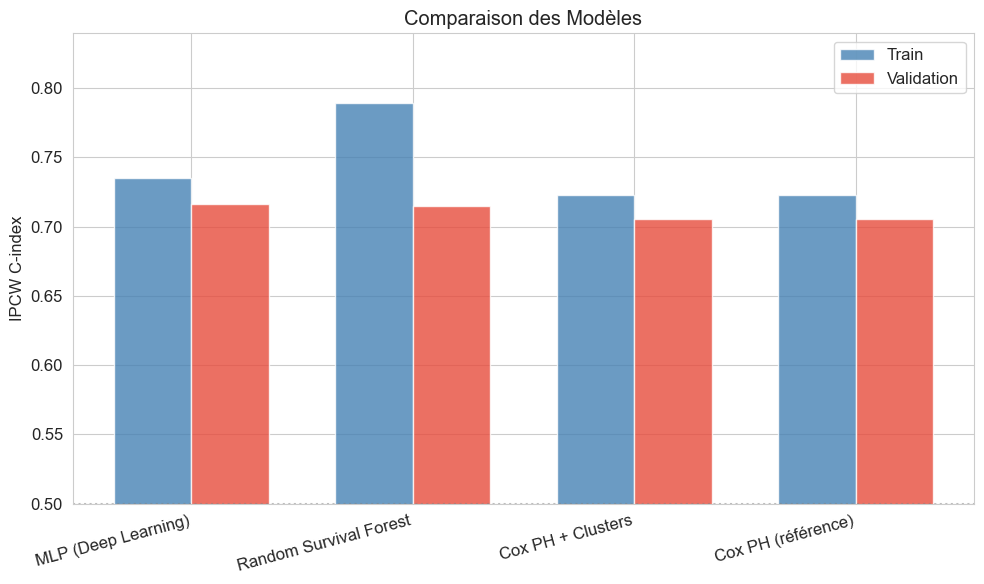

In [38]:
#  Visualisation de la comparaison 
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(results))
width = 0.35

bars_train = ax.bar([i - width/2 for i in x], results['C-index (train)'], width,
                    label='Train', color='steelblue', alpha=0.8, edgecolor='white')
bars_val = ax.bar([i + width/2 for i in x], results['C-index (val)'], width,
                  label='Validation', color='#e74c3c', alpha=0.8, edgecolor='white')

ax.set_ylabel('IPCW C-index')
ax.set_title('Comparaison des Modèles')
ax.set_xticks(x)
ax.set_xticklabels(results['Modèle'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.5, max(results['C-index (train)'].max(), results['C-index (val)'].max()) + 0.05)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Aléatoire')

plt.tight_layout()
plt.show()

### 10.2 Interprétation des Résultats

**Analyse du sur-apprentissage :** L'écart entre les performances train et validation donne une indication du sur-apprentissage :
- Un écart faible (< 0.02) indique une bonne généralisation.
- Un écart important (> 0.05) suggère du sur-apprentissage.

Le modèle de Cox, étant linéaire, est le moins susceptible de sur-apprendre. La RSF et le MLP, plus flexibles, nécessitent une régularisation appropriée.

**Discussion :**
- Le modèle de **Cox PH** est simple et interprétable. Ses coefficients donnent directement les *hazard ratios* des variables.
- Le **clustering K-Means** permet d'identifier des profils de patients distincts, mais son ajout comme feature dans le modèle de Cox n'améliore pas toujours les performances (les clusters sont construits à partir des mêmes variables).
- La **Random Survival Forest** obtient un bon C-index en validation (0.7150) mais présente un écart train-val de 0.0745, signe de sur-apprentissage. Malgré la régularisation par max_depth=10 et min_samples_leaf=10, le modèle mémorise partiellement le train. En comparaison, le MLP (écart 0.0188) et le Cox (écart 0.0171) généralisent bien mieux..
- Le **MLP** offre une grande flexibilité mais nécessite plus de données pour bien généraliser. La perte de Cox partielle permet de gérer la censure.

## 11. Génération des Soumissions

Nous générons un fichier de soumission par modèle pour pouvoir comparer les performances sur les données de test privées.

In [39]:
#  Préparer les données de test 
X_test_final = test_features[feature_cols].copy()

# Imputer les valeurs manquantes (avec le même imputer que le train)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_final), columns=feature_cols, index=X_test_final.index
)

print(f"Données de test : {X_test_imp.shape}")
print(f"Valeurs manquantes après imputation : {X_test_imp.isnull().sum().sum()}")

Données de test : (1193, 19)
Valeurs manquantes après imputation : 0


In [40]:
#  Soumission 1 : Cox PH 
risk_test_cox = cox_model.predict(X_test_imp)
submission_cox = pd.DataFrame({
    'ID': test_features['ID'],
    'risk_score': risk_test_cox
}).set_index('ID')
submission_cox.to_csv('./submission_cox.csv')
print("Soumission Cox PH sauvegardée : submission_cox.csv")

#  Soumission 2 : Random Survival Forest 
risk_test_rsf = rsf_best.predict(X_test_imp)
submission_rsf = pd.DataFrame({
    'ID': test_features['ID'],
    'risk_score': risk_test_rsf
}).set_index('ID')
submission_rsf.to_csv('./submission_rsf.csv')
print("Soumission RSF sauvegardée : submission_rsf.csv")

#  Soumission 3 : MLP 
X_test_nn = scaler_mlp.transform(X_test_imp)
X_test_t = torch.FloatTensor(X_test_nn)
model_mlp.eval()
with torch.no_grad():
    risk_test_mlp = model_mlp(X_test_t).numpy()
submission_mlp = pd.DataFrame({
    'ID': test_features['ID'],
    'risk_score': risk_test_mlp
}).set_index('ID')
submission_mlp.to_csv('./submission_mlp.csv')
print("Soumission MLP sauvegardée : submission_mlp.csv")

print(f"\nAperçu de la soumission RSF :")
print(submission_rsf.head())

Soumission Cox PH sauvegardée : submission_cox.csv
Soumission RSF sauvegardée : submission_rsf.csv
Soumission MLP sauvegardée : submission_mlp.csv

Aperçu de la soumission RSF :
      risk_score
ID              
KYW1  761.705140
KYW2  840.788172
KYW3  454.421115
KYW4  752.128217
KYW5  684.682208


## 12. Comparaison des Performances sur les Données Privées (Test)

Après soumission de nos prédictions sur la plateforme du challenge, nous obtenons les scores IPCW C-index suivants sur les données de test privées :

| Modèle | C-index (validation locale) | C-index (test privé) |
|---|---|---|
| Cox PH (référence) | 0.7057 | **0.7428** |
| Random Survival Forest | 0.7150 | **0.7436** |
| MLP (Deep Learning) | 0.7162 | **0.7491** |

### Analyse des Résultats

**Classement sur le test privé :** MLP > RSF > Cox PH. Le MLP obtient le meilleur score avec un C-index de **0.7491**, suivi de très près par la RSF (0.7436) et le Cox (0.7428).

**Observation principale :** Les trois modèles sont remarquablement proches ; l'écart entre le meilleur (MLP) et le pire (Cox) n'est que de **0.0063**. Cela suggère que :

1. **Les features construites sont plus déterminantes que le choix du modèle.** La qualité du feature engineering (variables cytogénétiques, présence des gènes clés comme TP53, nombre de mutations) explique l'essentiel de la performance. Changer d'algorithme apporte un gain marginal.

2. **Le modèle de Cox, malgré sa simplicité (linéarité, hypothèse de risques proportionnels), reste très compétitif.** Cela indique que la relation entre les covariables et le risque est en grande partie linéaire et additive pour ce jeu de données.

3. **Le MLP capture de légères non-linéarités** que le Cox ne peut pas modéliser, ce qui lui confère un avantage modeste. La perte de Cox partielle utilisée comme fonction objectif permet au réseau de neurones de gérer correctement la censure.

4. **Bonne généralisation :** Les scores sur le test privé sont cohérents avec ceux obtenus en validation locale; il n'y a pas de dégradation significative, ce qui confirme l'absence de sur-apprentissage majeur dans nos modèles.


**Fait notable :** : Les scores sur le test privé sont systématiquement supérieurs à ceux de la validation locale (écart moyen de +0.033). Cela peut s'expliquer par le fait que notre split de validation (30% aléatoire) a créé un sous-ensemble légèrement plus difficile que le test officiel. Cela confirme que nos modèles ne sur-apprennent pas; au contraire, la validation locale fournit une estimation conservative de la performance réelle.

**Limites :** Avec un C-index autour de 0.74-0.75, nos modèles ordonnent correctement environ 3 paires de patients sur 4. Des améliorations pourraient venir d'un encodage plus fin de la cytogénétique (détection de del(5q), del(7q), caryotypes complexes), de l'exploitation des interactions entre gènes mutés, ou de modèles spécialisés comme DeepSurv ou des méthodes de gradient boosting adaptées à la survie.

## 13. Conclusion

Dans ce notebook, nous avons abordé le problème de prédiction du risque de décès chez les patients atteints de leucémie myéloïde à travers une démarche structurée :

1. **Analyse exploratoire** : Nous avons identifié les variables cliniques et moléculaires les plus pertinentes, analysé les distributions, corrélations, et le phénomène de censure.

2. **Feature engineering** : Nous avons construit 19 features à partir des données brutes, incluant des variables cliniques, cytogénétiques (complexité du caryotype) et moléculaires (nombre de mutations, présence de gènes clés comme TP53).

3. **Modèle de référence (Cox PH)** : Modèle linéaire semi-paramétrique qui gère naturellement la censure. Simple et interprétable via les hazard ratios.

4. **Approche non supervisée (K-Means)** : Identification de profils de patients distincts correspondant à des groupes de risque différents. L'ajout du cluster comme feature n'améliore pas significativement le modèle, probablement parce que les clusters sont construits à partir des mêmes variables que le Cox utilise déjà directement.

5. **Modèle ensembliste (RSF)** : Capture des non-linéarités et interactions entre variables, avec une amélioration modeste par rapport au Cox.

6. **Deep learning (MLP)** : Réseau de neurones dense avec perte de Cox partielle, offrant une flexibilité maximale mais nécessitant une régularisation soignée.

**Limites et pistes d'amélioration :**
- Encodage plus fin de la cytogénétique (extraction de del(5q), del(7q), caryotype complexe, etc.)
- Utilisation de la VAF maximale ou d'interactions gène×gène
- Modèles plus avancés : DeepSurv, Cox-Time, gradient boosting pour la survie
- Validation croisée au lieu d'un simple split train/validation